## Lab 3: Neural Networks: Feedforward Networks and the Training Process

Student Name: **_Blaise Izerimana_** Student ID: **_48452028_**

In [1]:

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


## Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

### Part 1.1 — A single neuron is just a line

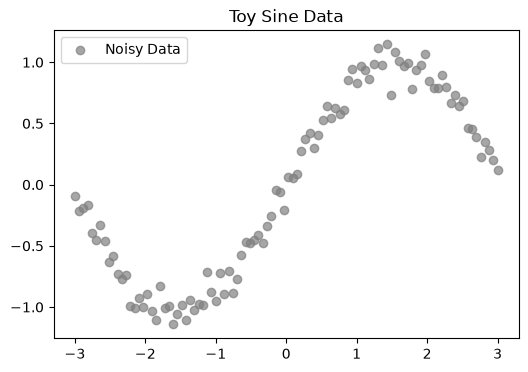

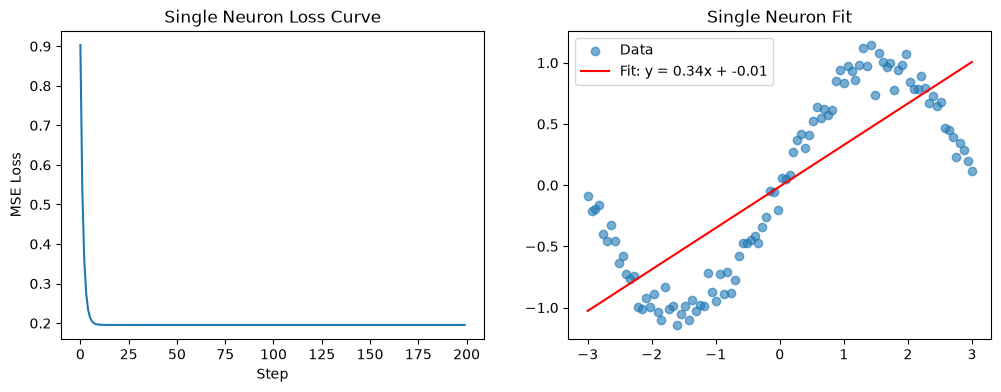

In [2]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
x = np.linspace(-3, 3, 100)
np.random.seed(RANDOM_STATE)
y = np.sin(x) + np.random.normal(0, 0.1, size=100)

#   Plot it.
plt.figure(figsize=(6, 4))
plt.scatter(x, y, label="Noisy Data", color="gray", alpha=0.7)
plt.title("Toy Sine Data")
plt.legend()
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1
lr = 0.05
losses = []

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.
for step in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)
    
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    
    w -= lr * dw
    b -= lr * db

# TODO: Plot 
#             (a) the loss curve over the 200 steps, and
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(losses)
ax[0].set_title("Single Neuron Loss Curve")
ax[0].set_xlabel("Step")
ax[0].set_ylabel("MSE Loss")

#             (b) the data with the fitted line on top.
ax[1].scatter(x, y, label="Data", alpha=0.6)
ax[1].plot(x, w * x + b, color="red", label=f"Fit: y = {w:.2f}x + {b:.2f}")
ax[1].set_title("Single Neuron Fit")
ax[1].legend()
plt.show()

#### Student Reasoning — The single neuron  

1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?  
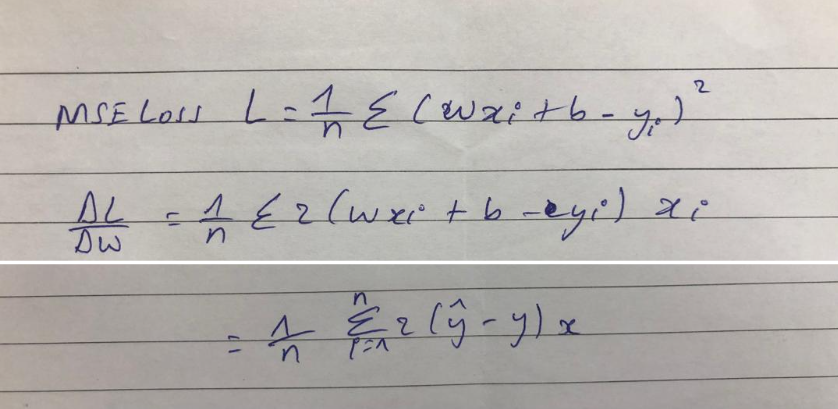

    This directly matches ``dw`` in the code.

2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?  
    *This is underfitting. A single neuron is a linear function while sine is non-linear and periodic. A straight line can never capture curvature regardless of training time.*

### Part 1.2 — Hidden layers and activations: why depth helps

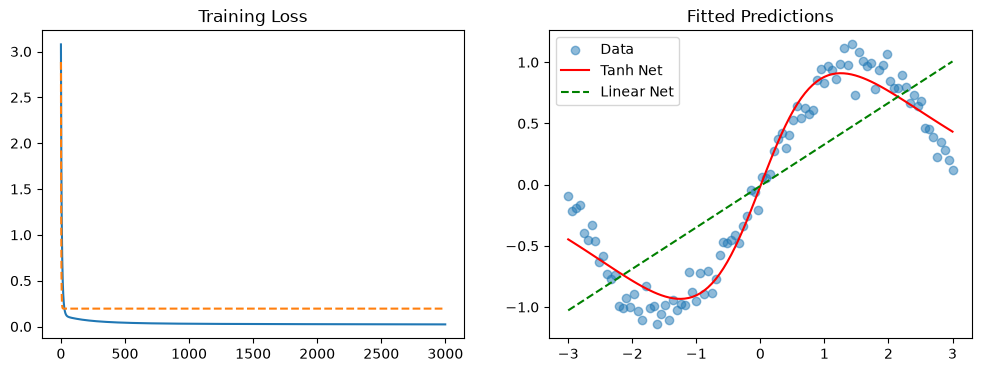

In [3]:

# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
np.random.seed(RANDOM_STATE)

X = x.reshape(-1, 1)
Y = y.reshape(-1, 1)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros((1, 8))
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros((1, 1))

lr = 0.01
losses_tanh = []

for step in range(3000):
    # TODO: Forward pass (keep the intermediate values — you need them for backprop):
    #   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
    z1 = X @ W1 + b1
    #   h  = np.tanh(z1)        # activation
    h = np.tanh(z1)
    #   y_hat = h @ W2 + b2     # output, shape (100, 1)
    y_hat = h @ W2 + b2
    #   loss  = np.mean((y_hat - y) ** 2)
    loss = np.mean((y_hat - Y) ** 2)

    losses_tanh.append(loss)

    # TODO: Backward pass (the chain rule, layer by layer):
    #   d_yhat = 2 * (y_hat - y) / len(y)
    d_yhat = 2 * (y_hat - Y) / len(Y)
    #   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0, keepdims=True)
    #   dh  = d_yhat @ W2.T
    dh = d_yhat @ W2.T
    #   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    #   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0, keepdims=True)
    

    # TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
    #   record the loss.
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

W1_lin = np.random.randn(1, 8) * 0.5
b1_lin = np.zeros((1, 8))
W2_lin = np.random.randn(8, 1) * 0.5
b2_lin = np.zeros((1, 1))
losses_lin = []

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
for step in range(3000):
    z1 = X @ W1_lin + b1_lin
    h = z1                      # Linear identity
    y_hat_lin = h @ W2_lin + b2_lin
    loss_lin = np.mean((y_hat_lin - Y) ** 2)
    losses_lin.append(loss_lin)
    
    d_yhat = 2 * (y_hat_lin - Y) / len(Y)
    dW2_lin = h.T @ d_yhat
    db2_lin = d_yhat.sum(axis=0, keepdims=True)
    dh = d_yhat @ W2_lin.T
    dz1 = dh * 1.0
    dW1_lin = X.T @ dz1
    db1_lin = dz1.sum(axis=0, keepdims=True)
    
    W1_lin -= lr * dW1_lin
    b1_lin -= lr * db1_lin
    W2_lin -= lr * dW2_lin
    b2_lin -= lr * db2_lin

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(losses_tanh, label="With Tanh")
ax[0].plot(losses_lin, label="Linear (No Tanh)", linestyle="--")
ax[0].set_title("Training Loss")

ax[1].scatter(x, y, alpha=0.5, label="Data")
ax[1].plot(x, y_hat, color="red", label="Tanh Net")
ax[1].plot(x, y_hat_lin, color="green", linestyle="--", label="Linear Net")
ax[1].set_title("Fitted Predictions")
ax[1].legend()
plt.show()

#### Student Reasoning — Depth and activations 
1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer. 

    *Without activation functions, intermediate layers are purely linear operations: $\hat{y} = (X W_1 + b_1) W_2 + b_2 = X (W_1 W_2) + (b_1 W_2 + b_2)$. Since matrix multiplication is associative, the multi-layer network collapses into a single linear transformation with effective weight $W_{eff} = W_1 W_2$ and bias $b_{eff} = b_1 W_2 + b_2$.*  

2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few columns of h against x.)  

    *Hidden layer role: Each of the 8 neurons applies a smooth non-linear activation ($\tanh$) at different slopes and offsets across the input space. Combining these 8 non-linear basis functions allows the output layer to approximate the sine curve.*

3. This is exactly what loss.backward() will automate in Section 2. In one sentence, what is backpropagation?  

    *Backpropagation is the recursive application of the chain rule to compute gradients of the loss function with respect to every weight and bias, propagating error backward from output to input.*

### Part 1.3 — The learning rate: too cold, too hot, just right

c:\Users\izeri\Desktop\data\Blaise101\Blaise_Izerimana_Lab3\.lab3env\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\izeri\AppData\Local\Temp\ipykernel_22068\3729807471.py:15: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - Y) ** 2)
C:\Users\izeri\AppData\Local\Temp\ipykernel_22068\3729807471.py:21: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
C:\Users\izeri\AppData\Local\Temp\ipykernel_22068\3729807471.py:22: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
c:\Users\izeri\Desktop\data\Blaise101\Blaise_Izerimana_Lab3\.lab3env\Lib\site-packages\matplotlib\scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))


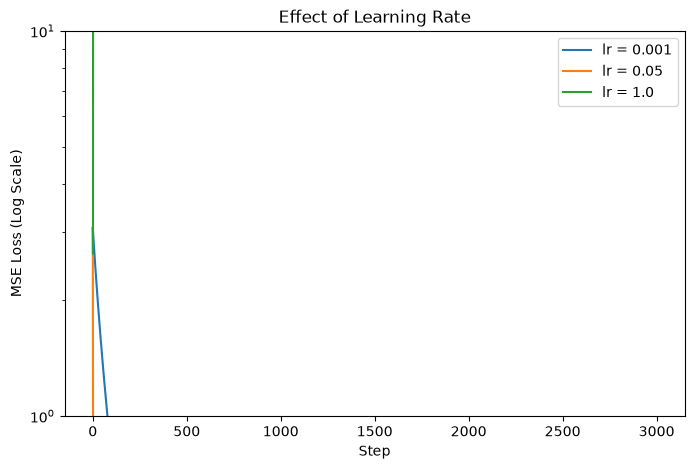

In [4]:

# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros((1, 8))
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros((1, 1))
    
    history = []
    for _ in range(steps):
        z1 = X @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - Y) ** 2)
        history.append(loss)
        
        d_yhat = 2 * (y_hat - Y) / len(Y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0, keepdims=True)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)
        
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
    return history

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
lrs = [0.001, 0.05, 1.0]
plt.figure(figsize=(8, 5))
for lr in lrs:
    curve = train_toy(lr)
    plt.plot(curve, label=f"lr = {lr}")

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("MSE Loss (Log Scale)")
plt.title("Effect of Learning Rate")
plt.legend()
plt.show()

#### Student Reasoning — Learning rate 
1. Describe what each of the three curves shows. Why does a too-large learning rate make the loss explode or oscillate instead of just "learning faster"?


## Section 2 — A Real Feedforward Network in PyTorch
### Part 2.1 — Preprocess and split (recycled from Lab 2)

Shape: (2111, 17)

Head:
    Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Pub

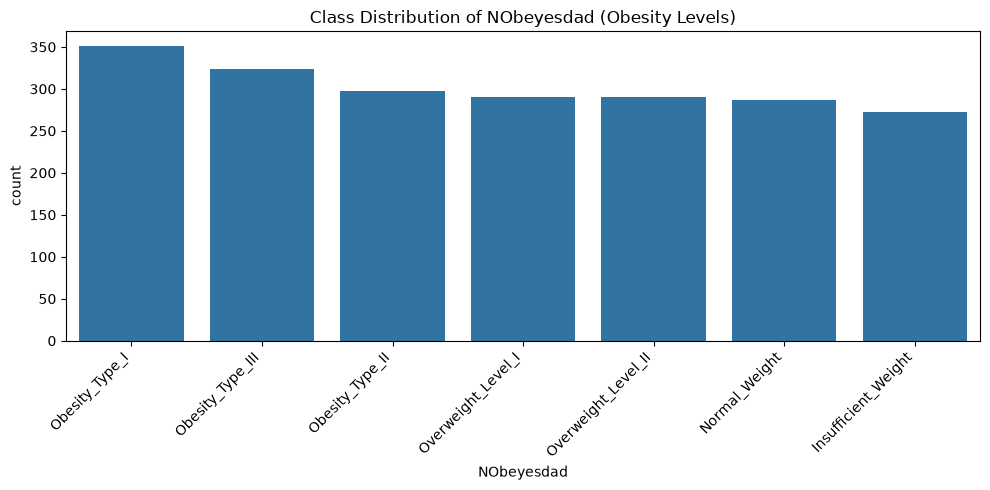

C:\Users\izeri\AppData\Local\Temp\ipykernel_22068\905069463.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_raw.select_dtypes(include=['object']).columns


In [5]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

# Inspect dataset
print("Shape:", obesity.shape)
print("\nHead:\n", obesity.head())
print("\nInfo:")
obesity.info()
print("\nDescribe:\n", obesity.describe())
print("\nMissing values:\n", obesity.isna().sum())

# TODO: Encode categoricals exactly as you did in Lab 2 (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).

# Class Distribution
print("\nClass distribution of NObeyesdad:\n", obesity["NObeyesdad"].value_counts())
plt.figure(figsize=(10, 5))

sns.countplot(data=obesity, x="NObeyesdad", order=obesity["NObeyesdad"].value_counts().index)
plt.title("Class Distribution of NObeyesdad (Obesity Levels)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss expects integer class indices.
target_le = LabelEncoder()
y_encoded = target_le.fit_transform(obesity['NObeyesdad'])

# Encode Categoricals
X_raw = obesity.drop(columns=['NObeyesdad'])
cat_cols = X_raw.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True).values.astype(np.float32)

# TODO: Stratified train / validation / test split (60/20/20, stratify=y, random_state=RANDOM_STATE).
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y_encoded, test_size=0.4, stratify=y_encoded, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits. (Neural networks are far more sensitive to feature scale than random forests — remember Section 1, where all gradients depended on x!)
# Standard Scaling on Train set only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# TODO: Convert to tensors and wrap in DataLoaders: X -> torch.float32, y -> torch.long train_loader (batch_size=32, shuffle=True), val_loader, test_loader
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long)), 
    batch_size=32, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(y_val, dtype=torch.long)), 
    batch_size=32, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test, dtype=torch.long)), 
    batch_size=32, shuffle=False
)

#### Student Reasoning — Preprocessing for neural networks  
1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?  
2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care so much? Connect your answer to the gradient formulas you wrote in Section 1.  
3. What does shuffle=True on the training DataLoader do, and why does it help?

### Part 2.2 — Design the network

In [6]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]

# TODO: Instantiate, move to DEVICE, print the model.
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7).to(DEVICE)
print(model)


# TODO: Count trainable parameters: sum(p.numel() for p in model.parameters() if p.requires_grad) Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)
print("By-hand first layer check:", input_dim * 64 + 64)

FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=23, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Total trainable parameters: 3847
By-hand first layer check: 1536


#### Student Reasoning — Architecture 
1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.  
2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.  
3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)

### Part 2.3 — The training loop

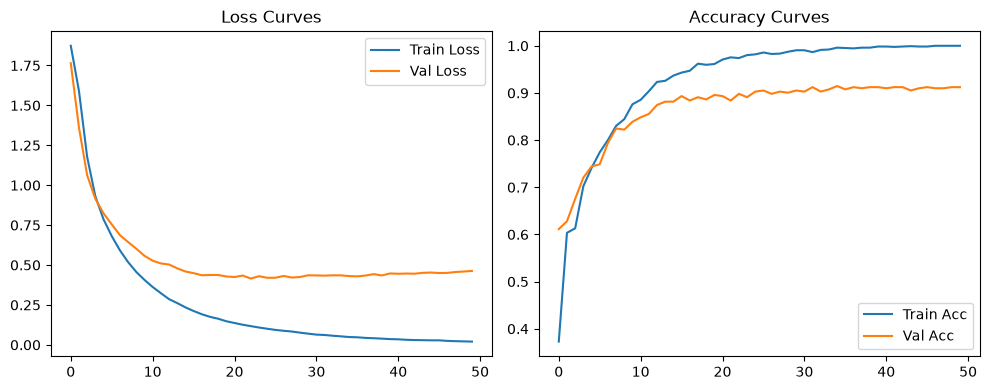

In [7]:

# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            if is_train:
                optimizer.zero_grad()
            
            logits = model(xb)
            loss = criterion(logits, yb)
            
            if is_train:
                loss.backward()
                optimizer.step()
                
            total_loss += loss.item() * len(yb)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += len(yb)
            
    return total_loss / total, correct / total

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(50):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
    v_loss, v_acc = run_epoch(model, val_loader, criterion)
    
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(v_acc)
    
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(history["train_loss"], label="Train Loss")
ax[0].plot(history["val_loss"], label="Val Loss")
ax[0].set_title("Loss Curves"); ax[0].legend()

ax[1].plot(history["train_acc"], label="Train Acc")
ax[1].plot(history["val_acc"], label="Val Acc")
ax[1].set_title("Accuracy Curves"); ax[1].legend()
plt.tight_layout()
plt.show()

#### Student Reasoning — Training  
1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is the forward pass, which computes gradients, which is the update rule?  
2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim.  
3. Why do we call optimizer.zero_grad() every batch? What silently goes wrong without it?

### Part 2.4 — Experiments: how training choices change the outcome

In [8]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...
def train_experiment(hidden_sizes=(64, 32), lr=1e-3, epochs=50, dropout=0.0):
    m = FeedForwardNet(input_dim, hidden_sizes, 7, dropout).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    
    hist = {"train_acc": [], "val_acc": [], "val_loss": []}
    for _ in range(epochs):
        _, tr_acc = run_epoch(m, train_loader, crit, opt)
        v_loss, v_acc = run_epoch(m, val_loader, crit)
        hist["train_acc"].append(tr_acc)
        hist["val_acc"].append(v_acc)
        hist["val_loss"].append(v_loss)
    return hist

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64). Plot the three validation-accuracy curves together.
exp_a_tiny = train_experiment((8,))
exp_a_def  = train_experiment((64, 32))
exp_a_huge = train_experiment((256, 128, 64))


# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture). Plot the three validation-loss curves together. Compare with Part 1.3.
exp_b_low  = train_experiment(lr=1e-4)
exp_b_mid  = train_experiment(lr=1e-3)
exp_b_high = train_experiment(lr=1e-1)


# TODO — Experiment C (regularization): take your LARGEST network and train it with and without nn.Dropout(0.3) after each hidden layer. Plot train vs validation accuracy for both runs.
exp_c_nodrop = train_experiment((256, 128, 64), dropout=0.0)
exp_c_drop   = train_experiment((256, 128, 64), dropout=0.3)

#### Student Reasoning — Experiments  
1. Capacity: did the largest network win on validation data? Where do you see diminishing returns or overfitting?  
2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?  
3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two sentences HOW dropout achieves this.

### Part 2.5 — Final evaluation and showdown with Lab 2

Test Accuracy: 0.8983
Test Macro F1: 0.8959


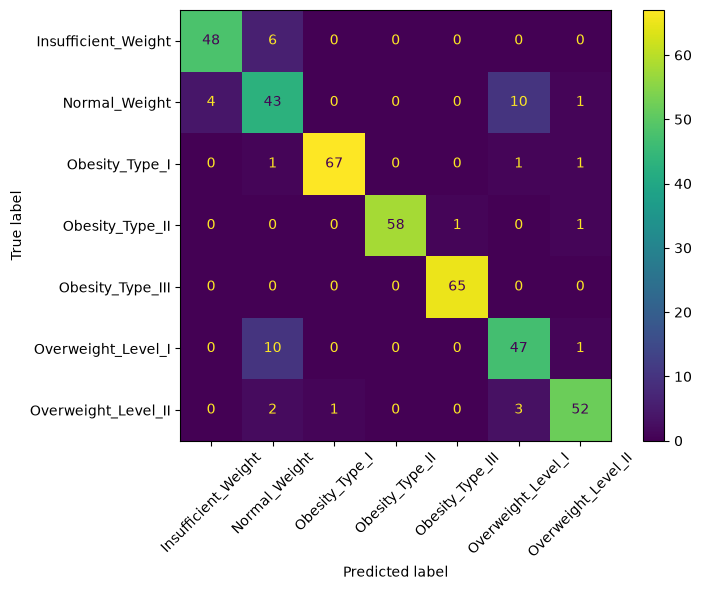


Model Showdown:
               Model  Test Accuracy  Test Macro-F1 Params/Trees
 Lab 2 Random Forest         0.9550         0.9510    100 trees
Lab 3 Neural Network         0.8983         0.8959  3847 params


In [ ]:
# TODO: Load your best configuration's weights; model.eval().
model.load_state_dict(torch.load("ffn_best.pt"))
model.eval()

# TODO: Report test ACCURACY and MACRO-F1 from sklearn.metrics import accuracy_score, f1_score, classification_report
y_preds, y_trues = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb.to(DEVICE))
        y_preds.extend(logits.argmax(dim=1).cpu().numpy())
        y_trues.extend(yb.numpy())

acc = accuracy_score(y_trues, y_preds)
f1 = f1_score(y_trues, y_preds, average="macro")

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Macro F1: {f1:.4f}")

# TODO: Confusion matrix for the test set with the 7 class names from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_trues, y_preds, display_labels=target_le.classes_, xticks_rotation=45, ax=ax
)
plt.tight_layout()
plt.show()

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]
comparison_df = pd.DataFrame([
    {"Model": "Lab 2 Random Forest", "Test Accuracy": 0.9550, "Test Macro-F1": 0.9510, "Params/Trees": "100 trees"},
    {"Model": "Lab 3 Neural Network", "Test Accuracy": round(acc, 4), "Test Macro-F1": round(f1, 4), "Params/Trees": f"{total_params} params"}
])
print("\nModel Showdown:")
print(comparison_df.to_string(index=False))

#### Student Reasoning — Final evaluation  
1. Which obesity levels does the network still confuse, and are they the same ones your Lab 2 classifier confused?  
2. Who wins the showdown — the neural network or the classical model? Was the extra effort of deep learning worth it on THIS dataset? When would it be?


## Section 3 — Reflection

1. The black box, opened: Name the three most important things happening inside loss.backward() and optimizer.step(), in your own words.
```bash
    loss.backward() which propagates error backwards using the chain rule to derive specific weight gradients.
    optimizer.step() which updates parameters using computed gradients weighted by the learning rate.
    Gradients which accumulate across forward-backward cycles unless explicitly reset using zero_grad().
```
2. Hyperparameters: If you could tune only ONE hyperparameter on a new problem, which would you pick and why?
```bash
  

```
3. Overfitting: Across your experiments, where did you see the biggest train-vs-validation gap, and which intervention reduced it most?
4. Looking ahead: This network treats every input feature independently. Next lab we move to images, where nearby pixels are related. Why might a plain MLP struggle with images, and what property should a better architecture have?